# Exercise 5

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [36]:
# Before working with the data,
# we download and prepare all features

# load all examples from the file
data = np.genfromtxt("../datasets/winequality-white.csv", delimiter=";", skip_header=1)

print(f"{data.shape = }")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

data.shape = (4898, 12)


In [37]:
# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

for i in range(11):
    mean = np.mean(X_train[:, i])
    std = np.std(X_train[:, i])
    X_train[:, i] = (X_train[:, i] - mean) / std  # standardize training features
    X_test[:, i] = (X_test[:, i] - mean) / std  # standardize test features using training mean and std


In [38]:
print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

print(f"{X_train.shape = }, {y_train.shape = }")
print(f"{X_test.shape = }, {y_test.shape = }")

First example:
Features: [-0.06260036 -0.8790185   3.07923825  2.14845111 -0.17940754 -0.849691
 -0.55742249  1.24376342 -2.24084287  0.07359793 -0.80619348]
Quality: 6.0
X_train.shape = (3000, 11), y_train.shape = (3000,)
X_test.shape = (1898, 11), y_test.shape = (1898,)


# Problems

The goal is to implement the training of a neural network with one input layer, one hidden layer, and one output layer using gradient descent. We first (below) define the matrices and initialise with random values. We need W, b, W' and b'. The shapes will be:
  * W: (number of hidden nodes, number of inputs) named `W`
  * b: (number of hidden nodes) named `b`
  * W': (number of hidden nodes) named `Wp`
  * b': (one) named `bp`

Your tasks are:     
   * Implement a forward pass of the network as `dnn` (see below)
   * Implement a function that uses one data point to update the weights using gradient descent. You can follow the `update_weights` skeleton below
   * Now you can use the code below (training loop and evaluation) to train the network for multiple data points and even over several epochs. Try to find a set of hyperparameters (number of nodes in the hidden layer, learning rate, number of training epochs) that gives stable results. What is the best result (as measured by the loss on the training sample) you can get?

First we initialize the network parameters randomly, using a gaussian distribution with a standard deviation related to the number of inputs of the neuron.

In [39]:
# Initialise weights with suitable random distributions
hidden_nodes = 50  # number of nodes in the hidden layer
n_inputs = 11  # input features in the dataset

W = rng.standard_normal(size=(hidden_nodes, 11)) * np.sqrt(2.0 / n_inputs)
b = rng.standard_normal(size=hidden_nodes) * np.sqrt(2.0 / n_inputs)
Wp = rng.standard_normal(size=hidden_nodes) * np.sqrt(2.0 / hidden_nodes)
bp = rng.standard_normal(size=(1))

print(f"{W.shape = }, {b.shape = }")
print(f"{Wp.shape = }, {bp.shape = }")

W.shape = (50, 11), b.shape = (50,)
Wp.shape = (50,), bp.shape = (1,)


In [40]:
# You can use this implementation of the ReLu activation function
def relu(x: np.ndarray) -> np.ndarray:
    """Simple implementation of a rectified linear unit.

    Parameters
    ----------
    x : array_like
        Array of input features.

    Returns
    -------
    np.ndarray
        Array containig function values of the relu for
        each element of the input array.
    """
    return np.maximum(x, 0)

Here we implement the forward pass, using the affine relation of the inputs and the outputs of each layer. The explicit formula can be read in hint 1.

In [41]:
def dnn(
    x: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Wp: np.ndarray,
    bp: np.ndarray,
) -> np.ndarray:
    """Simple DNN.

    Parameters
    ----------
    x : array_like
        Array of input features.
    W : array_like
        Array of input layer weights.
    b : array_like
        Array of input layer biases.
    Wp : array__like
        Array of output layer weighs.
    bp : array_like
        Array of output layer biases

    Returns
    -------
    np.ndarray, shape (1,)
        Array containing the float output of the DNN.
    """
    
    y1 = relu(W @ x + b)  # hidden layer output
    y2 = Wp @ y1 + bp  # output layer output
    return y2

We create a function that computes the gradient. The expressions are found in hint 2. `np.outer` is used for the tensor product (two vectors create a matrix).

In [42]:
# You might need these numpy functions:
    # np.dot, np.outer, np.heaviside
    # Hint: Use .shape and print statements to make sure all operations
    # do what you want them to

def gradient(
    x: np.ndarray,
    y: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Wp: np.ndarray,
    bp: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Calculate the gradient of the loss function with respect to the weights and biases.

    Parameters
    ----------
    x : array_like
        Array of input features.
    y : array_like
        Array of true output values.
    W : array_like
        Array of input layer weights.
    b : array_like
        Array of input layer biases.
    Wp : array__like
        Array of output layer weighs.
    bp : array_like
        Array of output layer biases

    Returns
    -------
    tuple
        Tuple of gradients with respect to each parameter.
    """
    y_pred = dnn(x, W, b, Wp, bp)
    z = W @ x + b 

    gradient_bp = 2*(y_pred - y)
    gradient_Wp = gradient_bp * relu(z)
    gradient_b = gradient_bp * Wp * np.heaviside(z, 0)
    gradient_W = gradient_bp * np.outer((Wp * np.heaviside(z, 0)), x)

    return  gradient_W, gradient_b, gradient_Wp, gradient_bp

Now, we use the previous gradient function to update de weights.

In [43]:
def update_weights(
    x: np.ndarray,
    y: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Wp: np.ndarray,
    bp: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Updates weights for given inputs, targets,
    weights, and biases.

    Parameters
    ----------
    x : array_like
        Array of input features.
    y : array_like
        Array of target features.
    W : array_like
        Array of input layer weights.
    b : array_like
        Array of input layer biases.
    Wp : array__like
        Array of output layer weighs.
    bp : array_like
        Array of output layer biases

    Returns
    -------
    tuple
        Tuple of updated weight and bias arrays.
    """

    learning_rate =  1e-4

    grad_W, grad_b, grad_Wp, grad_bp = gradient(x, y, W, b, Wp, bp)  # gradient of the loss function with respect to the output layer output
    
    W_new = W - learning_rate * grad_W  # update input layer weights
    b_new = b - learning_rate * grad_b  # update input layer biases
    Wp_new = Wp - learning_rate * grad_Wp  # update output layer weights
    bp_new = bp - learning_rate * grad_bp  # update output layer biases

    return W_new, b_new, Wp_new, bp_new # return the new weights

# Training loop and evaluation below

We train the model, first using the default number of neurons in the hidden layer (50). 

In [44]:
# The code below implements the training.
# If you correctly implement  dnn and update_weights above,
# you should not need to change anything below.
# (apart from increasing the number of epochs)

train_losses = []
test_losses = []

# How many epochs to train
# This will just train for one epoch
# You will want a higher number once everything works
n_epochs = 100

# Loop over the epochs
for ep in range(n_epochs):
    # Each epoch is a complete over the training data
    for i in range(X_train.shape[0]):
        # pick one example
        x = X_train[i]
        y = y_train[i]

        # use it to update the weights
        W, b, Wp, bp = update_weights(x, y, W, b, Wp, bp)

    # Calculate predictions for the full training and testing sample
    y_pred_train = [dnn(x, W, b, Wp, bp)[0] for x in X_train]
    y_pred = [dnn(x, W, b, Wp, bp)[0] for x in X_test]

    # Calculate average loss / example over the epoch
    train_loss = np.sum((y_pred_train - y_train) ** 2) / y_train.shape[0]
    test_loss = np.sum((y_pred - y_test) ** 2) / y_test.shape[0]

    # print some information
    if ep % 10 == 0:  # print every 10 epochs
        print("Epoch:", ep, "Train Loss:", train_loss, "Test Loss:", test_loss)

    # and store the losses for later use
    train_losses.append(train_loss)
    test_losses.append(test_loss)

Epoch: 0 Train Loss: 2.94861670950359 Test Loss: 3.187781283132322
Epoch: 10 Train Loss: 0.6845130200739871 Test Loss: 0.7306627942420479
Epoch: 20 Train Loss: 0.5583941109384878 Test Loss: 0.5853962756307922
Epoch: 30 Train Loss: 0.5283339180235854 Test Loss: 0.5592517074074522
Epoch: 40 Train Loss: 0.5123894377123335 Test Loss: 0.5472214424870985
Epoch: 50 Train Loss: 0.5013625744248666 Test Loss: 0.5394860569393413
Epoch: 60 Train Loss: 0.49318809856970636 Test Loss: 0.5341122092094689
Epoch: 70 Train Loss: 0.48667317600226784 Test Loss: 0.5307179594898335
Epoch: 80 Train Loss: 0.48029921721193514 Test Loss: 0.5279485617741444
Epoch: 90 Train Loss: 0.4751630927864911 Test Loss: 0.5251915831894324


Test and train losses are similar, which is a sign that there is no overfitting. We are set to evaluate the results of the training.

Best loss: 0.5227393902028352 Final loss: 0.5227393902028352
Correlation coefficient: 0.573785058724269


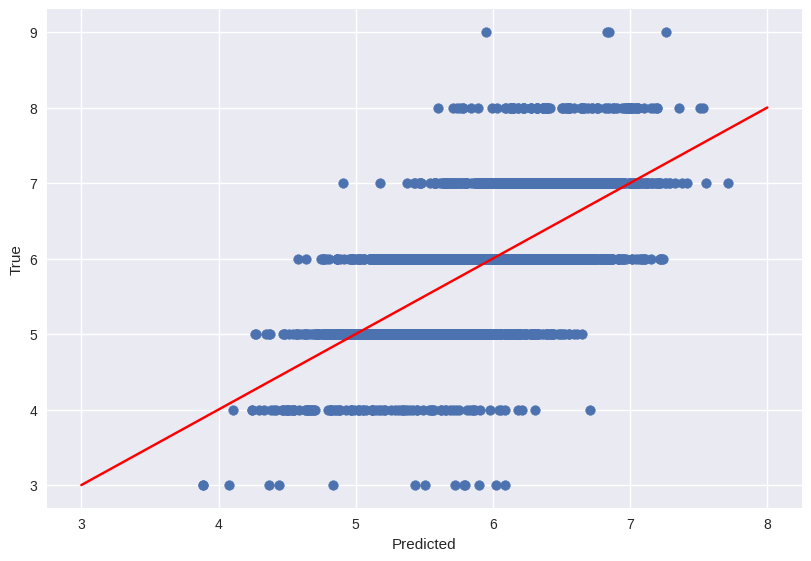

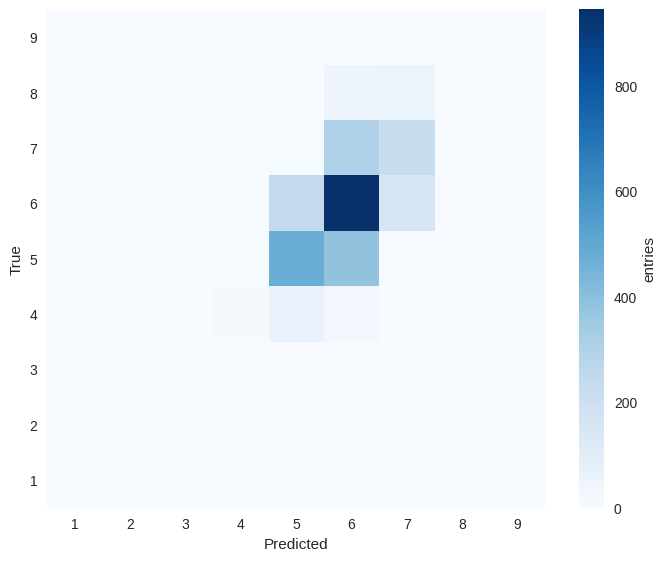

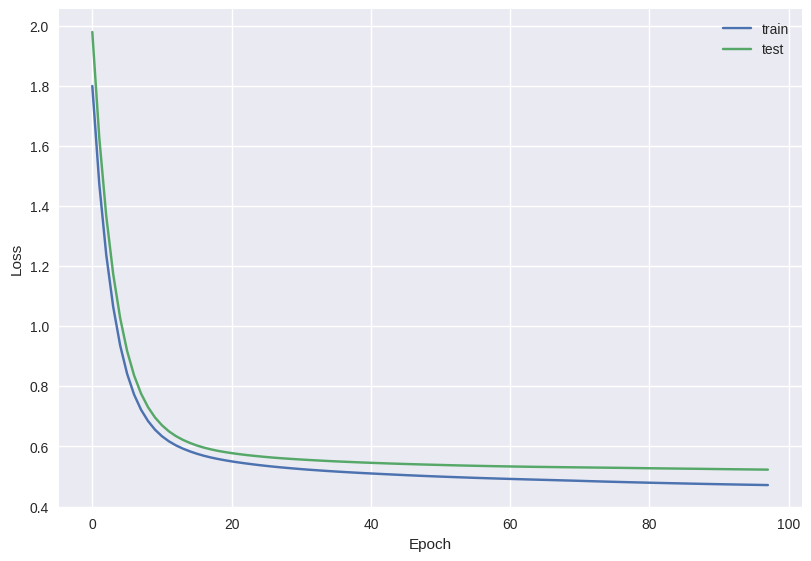

In [45]:
# After the training:

# Prepare scatter plot
y_pred = [dnn(x, W, b, Wp, bp)[0] for x in X_test]

print("Best loss:", min(test_losses), "Final loss:", test_losses[-1])

print("Correlation coefficient:", np.corrcoef(y_pred, y_test)[0, 1])
fig, ax = plt.subplots(layout="constrained")
ax.scatter(y_pred_train, y_train)
ax.plot([3, 8], [3, 8], "red")  # add a dashed line for reference
ax.set(
    xlabel="Predicted",
    ylabel="True",
)


fig, ax = plt.subplots(layout="constrained")
h = ax.hist2d(
    y_pred_train,
    y_train,
    bins=[np.arange(0.5, 10.5, 1), np.arange(0.5, 10.5, 1)],
    cmap="Blues",
)

ax.set(
    xlabel="Predicted",
    ylabel="True",
    aspect="equal",
)

cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label("entries")


# Prepare and loss over time
fig, ax = plt.subplots(layout="constrained")
ax.plot(train_losses[2:], label="train")
ax.plot(
    test_losses[2:], label="test"
)  # we omit the first data points as the first loss is typically very high which makes it difficult to read the plot.
ax.legend()
ax.set(
    xlabel="Epoch",
    ylabel="Loss",
);

We achieve a correlation coefficient of around 0.57, slightly better than the value 0.52 we had in exercise 4 (the simple linear regression). The improvement is not great. 

We can try to further increase the complexity of the model, adding 50 more neurons to the hidden layer, to a total of 100.

In [46]:
# Initialise weights with suitable random distributions
hidden_nodes = 100  # number of nodes in the hidden layer
n_inputs = 11  # input features in the dataset

W = rng.standard_normal(size=(hidden_nodes, 11)) * np.sqrt(2.0 / n_inputs)
b = rng.standard_normal(size=hidden_nodes) * np.sqrt(2.0 / n_inputs)
Wp = rng.standard_normal(size=hidden_nodes) * np.sqrt(2.0 / hidden_nodes)
bp = rng.standard_normal(size=(1))

print(f"{W.shape = }, {b.shape = }")
print(f"{Wp.shape = }, {bp.shape = }")

W.shape = (100, 11), b.shape = (100,)
Wp.shape = (100,), bp.shape = (1,)


Epoch: 0 Train Loss: 2.1301075317038514 Test Loss: 2.224497981278266
Epoch: 10 Train Loss: 0.6032018031234448 Test Loss: 0.6231565218155312
Epoch: 20 Train Loss: 0.5381487050876504 Test Loss: 0.561766992929446
Epoch: 30 Train Loss: 0.5108577858698229 Test Loss: 0.5411694735346082
Epoch: 40 Train Loss: 0.4947885452828364 Test Loss: 0.5310917349252257
Epoch: 50 Train Loss: 0.4833011710225445 Test Loss: 0.5246732877802742
Epoch: 60 Train Loss: 0.4749577087102363 Test Loss: 0.5203315447047933
Epoch: 70 Train Loss: 0.46813511486247483 Test Loss: 0.5176568238133944
Epoch: 80 Train Loss: 0.4624382939463027 Test Loss: 0.5156155403926759
Epoch: 90 Train Loss: 0.457645846200313 Test Loss: 0.513986484636237
Best loss: 0.5126282571001312 Final loss: 0.5126282571001312
Correlation coefficient: 0.5860152440999673


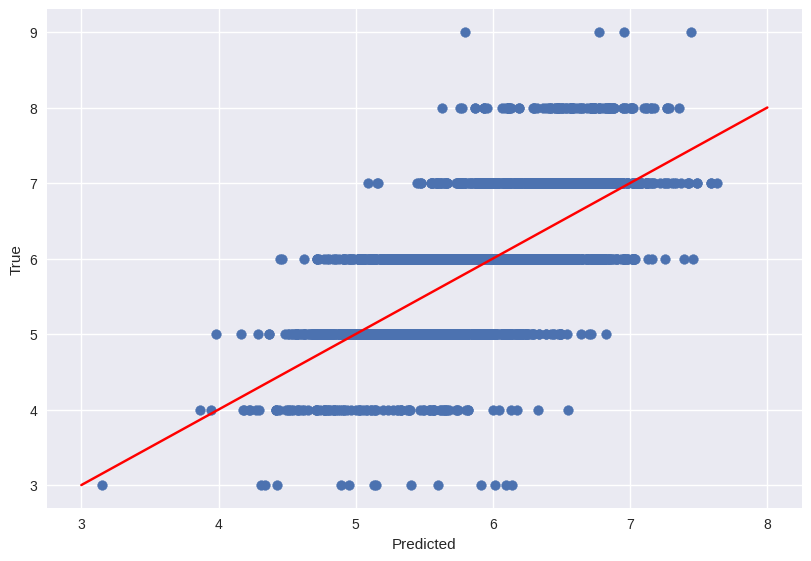

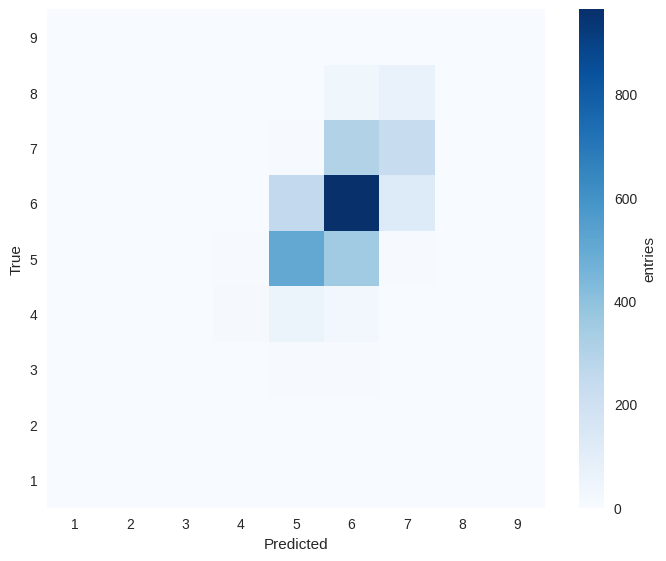

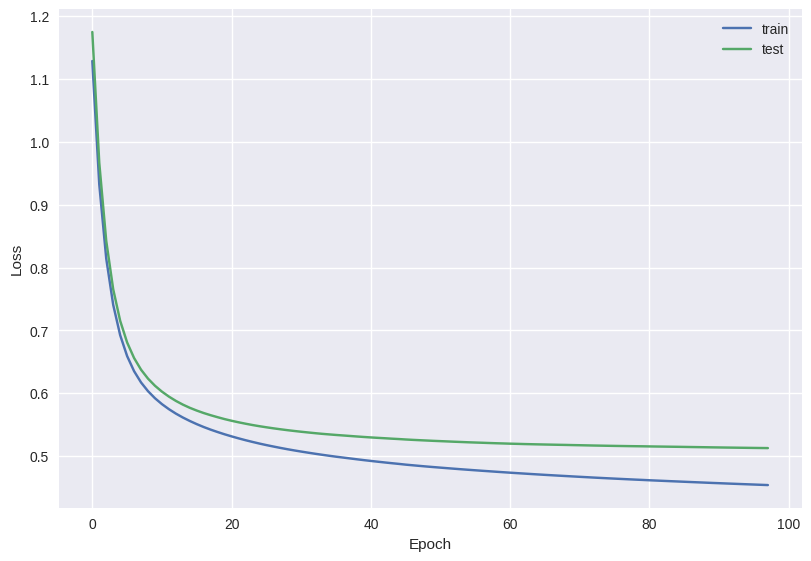

In [47]:
# The code below implements the training.
# If you correctly implement  dnn and update_weights above,
# you should not need to change anything below.
# (apart from increasing the number of epochs)

train_losses = []
test_losses = []

# How many epochs to train
# This will just train for one epoch
# You will want a higher number once everything works
n_epochs = 100

# Loop over the epochs
for ep in range(n_epochs):
    # Each epoch is a complete over the training data
    for i in range(X_train.shape[0]):
        # pick one example
        x = X_train[i]
        y = y_train[i]

        # use it to update the weights
        W, b, Wp, bp = update_weights(x, y, W, b, Wp, bp)

    # Calculate predictions for the full training and testing sample
    y_pred_train = [dnn(x, W, b, Wp, bp)[0] for x in X_train]
    y_pred = [dnn(x, W, b, Wp, bp)[0] for x in X_test]

    # Calculate average loss / example over the epoch
    train_loss = np.sum((y_pred_train - y_train) ** 2) / y_train.shape[0]
    test_loss = np.sum((y_pred - y_test) ** 2) / y_test.shape[0]

    # print some information
    if ep % 10 == 0:  # print every 10 epochs
        print("Epoch:", ep, "Train Loss:", train_loss, "Test Loss:", test_loss)

    # and store the losses for later use
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # After the training:

# Prepare scatter plot
y_pred = [dnn(x, W, b, Wp, bp)[0] for x in X_test]

print("Best loss:", min(test_losses), "Final loss:", test_losses[-1])

print("Correlation coefficient:", np.corrcoef(y_pred, y_test)[0, 1])
fig, ax = plt.subplots(layout="constrained")
ax.scatter(y_pred_train, y_train)
ax.plot([3, 8], [3, 8], "red")  # add a dashed line for reference
ax.set(
    xlabel="Predicted",
    ylabel="True",
)


fig, ax = plt.subplots(layout="constrained")
h = ax.hist2d(
    y_pred_train,
    y_train,
    bins=[np.arange(0.5, 10.5, 1), np.arange(0.5, 10.5, 1)],
    cmap="Blues",
)

ax.set(
    xlabel="Predicted",
    ylabel="True",
    aspect="equal",
)

cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label("entries")


# Prepare and loss over time
fig, ax = plt.subplots(layout="constrained")
ax.plot(train_losses[2:], label="train")
ax.plot(
    test_losses[2:], label="test"
)  # we omit the first data points as the first loss is typically very high which makes it difficult to read the plot.
ax.legend()
ax.set(
    xlabel="Epoch",
    ylabel="Loss",
);

The correlation coefficient increases by around 0.02, but the distance between the test and training loss also gets bigger. That makes me think that the (very small) improvement in the model comes with some more overfitting. In any case, the improvement is not really worth doubling the neurons in the hidden layer, which of course almost doubles the complexity of the model.

As a conclusion, I think the wine quality is not well predicted by the chemical properties we are using. Increasing the model complexity from a linear regression ($11$ parameters), to a neural network with 50 neurons in a hidden layer ($50\times11+50+50+1=651$ parameters), to a neural network with 100 neurons in a hidden layer ($100\times11+100+100+1=1301$ parameters) does not increase the performance of the predictions in a notable way. The dispersion of the predictions around the true value is still huge, especially predicting wrongly the high and low quality wines.

# Hint 1

We want a network with one hidden layer. As activiation in the hidden layer $\sigma$ we apply element-wise ReLu, while no activation is used for the output layer. The forward pass of the network then reads:
$$\hat{y}=\mathbf{W}^{\prime} \sigma(\mathbf{W} \vec{x}+\vec{b})+b^{\prime}$$

# Hint 2

For the regression problem the objective function is the mean squared error between the prediction and the true label $y$:
$$
L=(\hat{y}-y)^{2}
$$

Taking the partial derivatives - and diligently the applying chain rule - with respect to the different objects yields:

$$
\begin{aligned}
\frac{\partial L}{\partial b^{\prime}} &=2(\hat{y}-y) \\
\frac{\partial L}{\partial b_{k}} &=2(\hat{y}-y) \mathbf{W}_{k}^{\prime} \theta\left(\sum_{i} \mathbf{W}_{k i} x_{i}+b_{k}\right) \\
\frac{\partial L}{\partial \mathbf{W}_{k}^{\prime}} &=2(\hat{y}-y) \sigma\left(\sum_{i} \mathbf{W}_{k i} x_{i}+b_{k}\right) \\
\frac{\partial L}{\partial \mathbf{W}_{m k}} &=2(\hat{y}-y) \mathbf{W}_{m}^{\prime} \theta\left(\sum_{i} \mathbf{W}_{m i} x_{i}+b_{m}\right) x_{k}
\end{aligned}
$$

Here, $\Theta$ denotes the Heaviside step function.